# STIC-JPL Sensitivity Analysis with ECOv002 Cal-Val

This notebook performs a sensitivity analysis of the STIC-JPL model using ECOSTRESS Collection 2 Cal-Val data. It loads input data, processes it through the STIC-JPL model, and visualizes the impact of input perturbations on latent heat flux. The notebook also generates figures for publication and explores the relationship between surface temperature and latent heat flux.

## Import Required Libraries and Functions

This cell imports all necessary libraries and functions for data processing, model execution, statistical analysis, and plotting. It includes custom modules for the PT-JPL-SM model, sensitivity analysis, and net radiation calculations, as well as standard scientific Python libraries.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))

In [2]:
from typing import Callable
from os import makedirs
from os.path import join
import numpy as np
import pandas as pd
from verma_net_radiation import verma_net_radiation_table
from BESS_JPL import process_BESS_table
from STIC_JPL import process_STIC_table, load_ECOv002_calval_STIC_inputs
from monte_carlo_sensitivity import perturbed_run, sensitivity_analysis, divide_absolute_by_unperturbed
import matplotlib.pyplot as plt
from scipy.stats import mstats
import seaborn as sns
from matplotlib.ticker import FuncFormatter

## Set Normalization Function

This cell assigns the normalization function used to compare perturbed model outputs to the unperturbed baseline. The function `divide_absolute_by_unperturbed` is used for normalization in the sensitivity analysis.

In [3]:
normalization_function = divide_absolute_by_unperturbed

## Load and Filter Input Data

This cell loads the ECOSTRESS Cal-Val input data using a custom loader function and filters out rows where `fAPARmax` is zero. The resulting DataFrame is displayed for inspection.

In [4]:
input_df = load_ECOv002_calval_STIC_inputs()
input_df

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,KG_climate,CI,canopy_height_meters,COT,AOT,Ca,wind_speed_mps,vapor_gccm,ozone_cm,Rn_Wm2
0,0,US-NC3,ENF,Cfa,270.345200,78.53355,392.851840,307.021970,487.383423,118.916280,...,3,0.282353,20.642902,0,0,400,0,0,0.3,393.85710
1,1,US-Mi3,CVM,Dfb,232.141600,229.20093,640.118470,375.089300,106.825577,167.919460,...,4,0.286275,0.000000,0,0,400,0,0,0.3,643.47500
2,2,US-Mi3,CVM,Dfb,356.355740,335.23154,625.661700,284.686250,NaN,132.936340,...,4,0.286275,0.000000,0,0,400,0,0,0.3,628.76870
3,3,US-Mi3,CVM,Dfb,332.938400,326.68680,624.254330,251.414490,178.827545,141.132420,...,4,0.286275,0.000000,0,0,400,0,0,0.3,626.95960
4,4,US-Mi3,CVM,Dfb,286.854030,237.21654,511.082180,228.520170,154.791626,114.809410,...,4,0.286275,0.000000,0,0,400,0,0,0.3,513.13380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,1060,US-xAE,GRA,Cfa,70.923310,172.37459,81.645230,15.282976,NaN,56.385185,...,3,0.301961,0.000000,0,0,400,0,0,0.3,163.24739
1061,1061,US-xAE,GRA,Cfa,116.543190,121.81641,65.469320,22.186659,NaN,40.509410,...,3,0.301961,0.000000,0,0,400,0,0,0.3,166.19196
1062,1062,US-xAE,GRA,Cfa,129.880100,0.00000,118.777240,55.343586,NaN,52.403820,...,3,0.301961,0.000000,0,0,400,0,0,0.3,235.88159
1063,1063,US-xAE,GRA,Cfa,2.707851,140.38632,126.490524,40.434025,NaN,57.769722,...,3,0.301961,0.000000,0,0,400,0,0,0.3,247.87890


## Define Processing Function for Model Table

This cell defines a helper function that processes the input DataFrame through the Verma net radiation calculation and then the PT-JPL-SM model. This function is used in later analysis steps.

In [5]:
def forward_process(input_df: pd.DataFrame) -> pd.DataFrame:
    return process_STIC_table(
        # input_df=verma_net_radiation_table(input_df), 
        input_df=process_BESS_table(input_df),
        constrain_negative_LE=False,
        supply_SWin=False,
        upscale_to_daylight=True
    )

## Process Input Data Through Model

This cell applies the processing function to the filtered input data, running it through the Verma net radiation and PT-JPL-SM model, and displays the resulting DataFrame.

In [6]:
processed = forward_process(input_df)
processed

[2025-11-13 10:18:39 INFO] started extracting geometry from PT-JPL-SM input table
[2025-11-13 10:18:39 INFO] completed extracting geometry from PT-JPL-SM input table
[2025-11-13 10:18:39 INFO] started extracting time from PT-JPL-SM input table
[2025-11-13 10:18:39 INFO] completed extracting time from PT-JPL-SM input table
[2025-11-13 10:18:39 INFO] variable elevation_km min: 0.001 mean: 0.993 max: 3.504 nan: 0.00% (nan)
[2025-11-13 10:18:39 INFO] variable Ta_C min: -14.605 mean: 22.322 max: 39.710 nan: 0.00% (nan)
[2025-11-13 10:18:39 INFO] variable RH min: 0.273 mean: 0.427 max: 0.984 nan: 0.00% (nan)
[2025-11-13 10:18:39 INFO] variable NDVI_minimum min: -0.033 mean: 0.174 max: 0.591 nan: 0.00% (nan)
[2025-11-13 10:18:39 INFO] variable NDVI_maximum min: 0.314 mean: 0.628 max: 0.918 nan: 0.00% (nan)
[2025-11-13 10:18:39 INFO] variable C4_fraction min: 0.000 mean: 0.296 max: 0.939 nan: 0.00% (nan)
[2025-11-13 10:18:39 INFO] variable carbon_uptake_efficiency min: 0.080 mean: 0.083 max: 0

/Users/halverso/Projects/STIC-JPL/STIC_JPL/process_STIC_table.py:88: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ST_C = np.float64(np.array(input_df.ST_C))
/Users/halverso/Projects/STIC-JPL/STIC_JPL/process_STIC_table.py:89: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  emissivity = np.float64(np.array(input_df.EmisWB))
/Users/halverso/Projects/STIC-JPL/STIC_JPL/process_STIC_table.py:90: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  NDVI = np.float64(np.array(inp

[2025-11-13 10:18:39 INFO] * 24.576439208204476: 1
[2025-11-13 10:18:39 INFO] variable LE_5 (float64) with [312.05427613] unique values
[2025-11-13 10:18:39 INFO] * 312.0542761316401: 1
[2025-11-13 10:18:39 INFO] running STIC iteration 6 / 30
[2025-11-13 10:18:39 INFO] using variable Priestley-Taylor alpha with mean: 1.551
[2025-11-13 10:18:39 INFO] completed STIC iteration 6 / 30 with max LE change: 2.535 (0.020666791999246925 seconds)
[2025-11-13 10:18:39 INFO] variable SM_6 (float64) with [0.51381065] unique values
[2025-11-13 10:18:39 INFO] * 0.5138106453710227: 1
[2025-11-13 10:18:39 INFO] variable G_6 (float64) with [24.57643921] unique values
[2025-11-13 10:18:39 INFO] * 24.576439208204476: 1
[2025-11-13 10:18:39 INFO] variable LE_6 (float64) with [314.5895149] unique values
[2025-11-13 10:18:39 INFO] * 314.58951489919986: 1
[2025-11-13 10:18:39 INFO] running STIC iteration 7 / 30
[2025-11-13 10:18:39 INFO] using variable Priestley-Taylor alpha with mean: 1.574
[2025-11-13 10:18

/Users/halverso/Projects/STIC-JPL/STIC_JPL/process_STIC_table.py:88: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ST_C = np.float64(np.array(input_df.ST_C))
/Users/halverso/Projects/STIC-JPL/STIC_JPL/process_STIC_table.py:89: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  emissivity = np.float64(np.array(input_df.EmisWB))
/Users/halverso/Projects/STIC-JPL/STIC_JPL/process_STIC_table.py:90: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  NDVI = np.float64(np.array(inp

[2025-11-13 10:18:40 INFO] completed STIC iteration 2 / 30 with max LE change: 11.628 (0.012487250001868233 seconds)
[2025-11-13 10:18:40 INFO] variable SM_2 (float64) with [0.19571138] unique values
[2025-11-13 10:18:40 INFO] * 0.19571137815917142: 1
[2025-11-13 10:18:40 INFO] variable G_2 (float64) with [24.05687285] unique values
[2025-11-13 10:18:40 INFO] * 24.056872849034626: 1
[2025-11-13 10:18:40 INFO] variable LE_2 (float64) with [359.34755453] unique values
[2025-11-13 10:18:40 INFO] * 359.34755452605214: 1
[2025-11-13 10:18:40 INFO] running STIC iteration 3 / 30
[2025-11-13 10:18:40 INFO] using variable Priestley-Taylor alpha with mean: 1.496
[2025-11-13 10:18:40 INFO] completed STIC iteration 3 / 30 with max LE change: 8.613 (0.0188872500002617 seconds)
[2025-11-13 10:18:40 INFO] variable SM_3 (float64) with [0.18735603] unique values
[2025-11-13 10:18:40 INFO] * 0.18735602884694336: 1
[2025-11-13 10:18:40 INFO] variable G_3 (float64) with [24.05687285] unique values
[2025-1

...

[2025-11-13 10:19:23 INFO] completed extracting geometry from PT-JPL-SM input table
[2025-11-13 10:19:23 INFO] started extracting time from PT-JPL-SM input table
[2025-11-13 10:19:23 INFO] completed extracting time from PT-JPL-SM input table
[2025-11-13 10:19:23 INFO] variable Ms (float64) with [0.25934021] unique values
[2025-11-13 10:19:24 INFO] * 0.2593402094996955: 1
[2025-11-13 10:19:24 INFO] running STIC iteration 1 / 30
[2025-11-13 10:19:24 INFO] using variable Priestley-Taylor alpha with mean: 1.239
[2025-11-13 10:19:24 INFO] completed STIC iteration 1 / 30 with max LE change: 7.986 (0.0024513340031262487 seconds)
[2025-11-13 10:19:24 INFO] variable SM_1 (float64) with [0.0908397] unique values
[2025-11-13 10:19:24 INFO] * 0.09083970198411591: 1
[2025-11-13 10:19:24 INFO] variable G_1 (float64) with [71.30841664] unique values
[2025-11-13 10:19:24 INFO] * 71.308416644595: 1
[2025-11-13 10:19:24 INFO] variable LE_1 (float64) with [355.94927341] unique values
[2025-11-13 10:19:24

/Users/halverso/Projects/STIC-JPL/STIC_JPL/process_STIC_table.py:88: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ST_C = np.float64(np.array(input_df.ST_C))
/Users/halverso/Projects/STIC-JPL/STIC_JPL/process_STIC_table.py:89: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  emissivity = np.float64(np.array(input_df.EmisWB))
/Users/halverso/Projects/STIC-JPL/STIC_JPL/process_STIC_table.py:90: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  NDVI = np.float64(np.array(inp

[2025-11-13 10:19:24 INFO] variable Ms (float64) with [0.] unique values
[2025-11-13 10:19:24 INFO] * 0.0: 1
[2025-11-13 10:19:24 INFO] running STIC iteration 1 / 30
[2025-11-13 10:19:24 INFO] using variable Priestley-Taylor alpha with mean: 2.119
[2025-11-13 10:19:24 INFO] completed STIC iteration 1 / 30 with max LE change: 0.464 (0.0007634999928995967 seconds)
[2025-11-13 10:19:24 INFO] variable SM_1 (float64) with [0.] unique values
[2025-11-13 10:19:24 INFO] * 0.0: 1
[2025-11-13 10:19:24 INFO] variable G_1 (float64) with [53.2715577] unique values
[2025-11-13 10:19:24 INFO] * 53.271557700638: 1
[2025-11-13 10:19:24 INFO] variable LE_1 (float64) with [6.72255251] unique values
[2025-11-13 10:19:24 INFO] * 6.72255251158527: 1
[2025-11-13 10:19:24 INFO] max LE change 0.464 within convergence target 2.0 with 1 iteration
[2025-11-13 10:19:24 INFO] started daily ET upscaling (STIC-JPL)
[2025-11-13 10:19:24 WARNING] Error processing row 1062: unsupported operand type(s) for -: 'NoneType' 

/Users/halverso/Projects/STIC-JPL/STIC_JPL/process_STIC_table.py:88: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ST_C = np.float64(np.array(input_df.ST_C))
/Users/halverso/Projects/STIC-JPL/STIC_JPL/process_STIC_table.py:89: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  emissivity = np.float64(np.array(input_df.EmisWB))
/Users/halverso/Projects/STIC-JPL/STIC_JPL/process_STIC_table.py:90: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  NDVI = np.float64(np.array(inp

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,Rn_soil_Wm2,Rn_canopy_Wm2,LE_Wm2,LE_soil_Wm2,LE_canopy_Wm2,G_Wm2,ET_daylight_kg,ET_daily_kg,EF,Rn_daylight_Wm2
0,0,US-NC3,ENF,Cfa,270.345200,78.53355,392.851840,307.021970,487.383423,118.916280,...,343.088141,200.486306,253.346657,69.342528,184.004129,37.045927,NaN,NaN,NaN,NaN
1,1,US-Mi3,CVM,Dfb,232.141600,229.20093,640.118470,375.089300,106.825577,167.919460,...,568.929428,176.618973,225.765314,100.628336,125.136978,75.785976,NaN,NaN,NaN,NaN
2,2,US-Mi3,CVM,Dfb,356.355740,335.23154,625.661700,284.686250,NaN,132.936340,...,595.207535,201.872465,346.807840,210.893323,135.914517,77.675719,NaN,NaN,NaN,NaN
3,3,US-Mi3,CVM,Dfb,332.938400,326.68680,624.254330,251.414490,178.827545,141.132420,...,539.752171,195.049305,336.703432,207.202548,129.500884,69.717555,NaN,NaN,NaN,NaN
4,4,US-Mi3,CVM,Dfb,286.854030,237.21654,511.082180,228.520170,154.791626,114.809410,...,441.941830,158.185783,259.677956,140.032444,119.645512,57.794590,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,1060,US-xAE,GRA,Cfa,70.923310,172.37459,81.645230,15.282976,NaN,56.385185,...,165.684047,69.659646,46.681268,41.487784,5.193484,29.244793,NaN,NaN,NaN,NaN
1061,1061,US-xAE,GRA,Cfa,116.543190,121.81641,65.469320,22.186659,NaN,40.509410,...,190.262323,75.928297,42.918736,31.172926,11.745809,32.896598,NaN,NaN,NaN,NaN
1062,1062,US-xAE,GRA,Cfa,129.880100,0.00000,118.777240,55.343586,NaN,52.403820,...,266.716370,138.943197,47.368643,6.239409,41.129234,35.811898,NaN,NaN,NaN,NaN
1063,1063,US-xAE,GRA,Cfa,2.707851,140.38632,126.490524,40.434025,NaN,57.769722,...,247.995207,66.902355,59.134543,48.996907,10.137635,44.868324,NaN,NaN,NaN,NaN


In [7]:
processed = processed.dropna(subset=['LEcorr50', 'ET_daylight_kg', 'ST_C'])
processed

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,Rn_soil_Wm2,Rn_canopy_Wm2,LE_Wm2,LE_soil_Wm2,LE_canopy_Wm2,G_Wm2,ET_daylight_kg,ET_daily_kg,EF,Rn_daylight_Wm2


## Accuracy Comparison of In-Situ Latent Heat Flux to STIC-JPL Latent Heat Flux

TypeError: expected non-empty vector for x

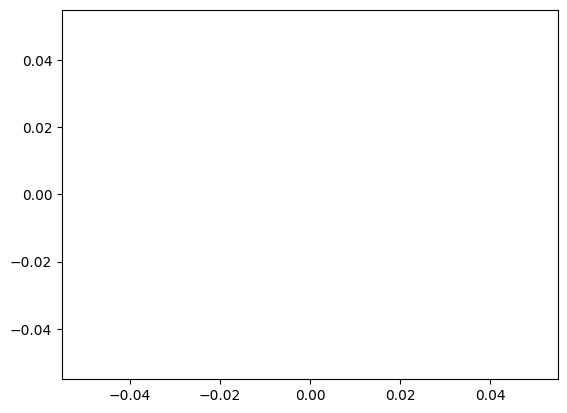

In [8]:
sc = plt.scatter(
    x=processed.LEcorr50,
    y=processed.LE_Wm2,
    c=processed.ST_C,
    cmap="jet",
    color=None,
    s=5
)

# Add 1-to-1 line
min_val = min(processed.LEcorr50.min(), processed.LE_Wm2.min())
max_val = max(processed.LEcorr50.max(), processed.LE_Wm2.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='-', linewidth=1, label='1:1 Line')

# Add OLS regression line
coefs = np.polyfit(processed.LEcorr50, processed.LE_Wm2, 1)
ols_x = np.array([min_val, max_val])
ols_y = coefs[0] * ols_x + coefs[1]
plt.plot(ols_x, ols_y, color='black', linestyle='--', linewidth=1, label='OLS Fit')

# Calculate R-squared and RMSE
from sklearn.metrics import r2_score, mean_squared_error
y_true = processed.LE_Wm2
y_pred = coefs[0] * processed.LEcorr50 + coefs[1]
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# Annotate R-squared and RMSE on plot in lower left corner
plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.1f}",
             xy=(0.05, 0.05), xycoords='axes fraction',
             ha='left', va='bottom',
             fontsize=10,
             bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.7))

# Set ticks every 100 for both axes
xticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
yticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
plt.xticks(xticks)
plt.yticks(yticks)

plt.grid(True, zorder=0) 
plt.xlabel("In-Situ Latent Heat Flux (W/m$^2$)")
plt.ylabel("STIC-JPL Latent Heat Flux (W/m$^2$)")
plt.title("Accuracy Comparison\nof In-Situ Latent Heat Flux\nto STIC-JPL Latent Heat Flux")
plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
plt.legend(loc='upper right')
plt.savefig("Accuracy Comparison of In-Situ Latent Heat Flux to STIC-JPL Latent Heat Flux.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Accuracy Comparison of In-Situ Latent Heat Flux to STIC-JPL Latent Heat Flux.svg", format='svg', bbox_inches='tight')
plt.show()

## Plot Unperturbed Comparison of Surface Temperature to Latent Heat Flux

This cell creates a scatter plot comparing ECOSTRESS surface temperature to STIC-JPL latent heat flux for the unperturbed data. The plot is saved as both JPEG and SVG files for publication or further analysis.

In [ ]:
plt.xticks(range(int(min(processed.ST_C)), int(max(processed.ST_C)) + 1, 5))
plt.scatter(x=processed.ST_C, y=processed.LE, color='black', s=10, zorder=5)
plt.grid(True, zorder=0)
plt.xlabel("ECOSTRESS Surface Temperature (°C)")
plt.ylabel("STIC-JPL Latent Heat Flux (W/m$^2$)")
plt.title("Unperturbed Comparison\nof ECOSTRESS Surface Temperature\nto STIC-JPL Latent Heat Flux")

plt.savefig("Unperturbed Comparison of ECOSTRESS Surface Temperature to STIC-JPL Latent Heat Flux.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Unperturbed Comparison of ECOSTRESS Surface Temperature to STIC-JPL Latent Heat Flux.svg", format='svg', bbox_inches='tight')

plt.show()

## Further Filter Input Data and Check Temperature Range

This cell applies additional filters to the input data, ensuring only valid `NDVI` values are included. It also checks the minimum and maximum surface temperature values in the filtered dataset.

In [ ]:
# input_df = pd.read_csv(input_filename)
input_df = load_ECOv002_calval_STIC_inputs()

if "Ta" in input_df and "Ta_C" not in input_df:
    # input_df.rename({"Ta": "Ta_C"}, inplace=True)
    input_df["Ta_C"] = input_df["Ta"]

input_df = input_df[input_df.NDVI.apply(lambda NDVI: NDVI > 0.05)]

np.nanmin(input_df.ST_C), np.nanmax(input_df.ST_C)

## Check Number of Valid Input Rows

This cell displays the number of rows remaining in the input DataFrame after all filtering steps, confirming the size of the dataset used for analysis.

In [ ]:
len(input_df)

## Run Perturbed Model Analysis

This cell sets up the input and output variables for the sensitivity analysis and runs the `perturbed_run` function, which perturbs the input variable and observes the effect on the output variable using the PM-JPL model. The results are displayed for further analysis.

In [ ]:
input_variable = "ST_C"
output_variable = "LE_Wm2"

results = perturbed_run(
    input_df=input_df, 
    input_variable=input_variable, 
    output_variable=output_variable, 
    forward_process=forward_process,
    normalization_function=normalization_function
)

results

## Filter Out NaN Results

This cell removes any rows with missing values from the perturbed results to ensure only valid data points are used in subsequent analysis and plotting.

In [ ]:
filtered_results = results.dropna()
filtered_results

## Plot Change in Surface Temperature vs Latent Heat Flux

This cell generates a scatter plot showing the relationship between changes in surface temperature and changes in PM-JPL latent heat flux due to input perturbations. The plot is saved as JPEG and SVG files.

In [ ]:
# plt.xticks(range(int(min(processed.ST_C)), int(max(processed.ST_C)) + 1, 5))
# plt.ylim(-350, 150)
plt.scatter(x=results.input_perturbation, y=results.output_perturbation, color='black', s=10, zorder=5)  # Adjust the 's' parameter to make dots thinner
plt.grid(True, zorder=0)
plt.xlabel("Change in Surface Temperature (°C)")
plt.ylabel("Change in STIC-JPL Latent Heat Flux (W/m$^2$)")
plt.title("Comparison of Change\nin Surface Temperature\nto STIC-JPL Latent Heat Flux")

plt.savefig("Comparison of Change in Surface Temperature to STIC-JPL Latent Heat Flux.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Comparison of Change in Surface Temperature to STIC-JPL Latent Heat Flux.svg", format='svg', bbox_inches='tight')

plt.show()

In [ ]:
sc = plt.scatter(
    x=results.input_perturbation, 
    y=results.output_perturbation, 
    c=results.input_unperturbed, 
    color=None,
    cmap="jet",
    s=3,
    alpha=0.5, 
    zorder=5
)

plt.grid(True, zorder=0)
plt.xlabel("Change in Surface Temperature (°C)")
plt.ylabel("Change in STIC-JPL Latent Heat Flux (W/m$^2$)")
plt.title("Comparison of Change\nin Surface Temperature\nto STIC-JPL Latent Heat Flux")
plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
plt.savefig("Comparison of Change in Surface Temperature to STIC-JPL Latent Heat Flux.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Comparison of Change in Surface Temperature to STIC-JPL Latent Heat Flux.svg", format='svg', bbox_inches='tight')

plt.show()

## Compute Correlation Between Input and Output Perturbations

This cell calculates the Pearson correlation coefficient between the standardized input and output perturbations, quantifying the strength of their linear relationship.

In [ ]:
correlation = mstats.pearsonr(
    np.array(filtered_results.input_perturbation_std).astype(np.float64), 
    np.array(filtered_results.output_perturbation_std).astype(np.float64)
)[0]

correlation

## Run Full Sensitivity Analysis for Multiple Inputs

This cell performs a comprehensive sensitivity analysis by perturbing several input variables (surface temperature, NDVI, albedo, air temperature, relative humidity) and measuring their effect on latent heat flux. The results are summarized in a DataFrame.

In [ ]:
input_variables = ["ST_C", "NDVI", "albedo", "Ta_C", "RH"]
output_variables = ["LE_Wm2"]

perturbation_df, sensitivity_metrics_df = sensitivity_analysis(
    input_df=input_df,
    input_variables=input_variables,
    output_variables=output_variables,
    forward_process=forward_process,
    normalization_function=normalization_function
)

sensitivity_metrics_df

## Plot Sensitivity Magnitude Bar Chart

This cell creates a bar chart showing the average percent change in latent heat flux for each input variable, visualizing the magnitude of model sensitivity to each input. The plot is saved as JPEG and SVG files with the PT-JPL-SM label.

In [ ]:
df = sensitivity_metrics_df
df = df[(df.output_variable == "LE_Wm2") & (df.metric == "mean_normalized_change")]
ax = sns.barplot(x=df.input_variable, y=df.value * 100, color='black')
ax.set_xticklabels(["Surface\nTemperature", "NDVI", "Albedo", "Air\nTemperature", "Relative\nHumidity"])
plt.xlabel("Input Variable")
plt.ylabel("Average Percent Change in Output Perturbation")
plt.title("STIC-JPL Latent Heat Flux Sensitivity Magnitude")
# plt.ylim(0, 160)  # Set y-axis range from 0 to 160
plt.grid(axis='y', color='lightgray', linestyle='-', linewidth=0.5)  # Add light gray horizontal gridlines only

# Add percent sign to y-axis tick labels
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y)}%'))

plt.savefig("STIC-JPL Latent Heat Flux Sensitivity Magnitude.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("STIC-JPL Latent Heat Flux Sensitivity Magnitude.svg", format='svg', bbox_inches='tight')

plt.show()

## Summary and Next Steps

This notebook demonstrated a full sensitivity analysis workflow for the PT-JPL-SM model using ECOSTRESS Cal-Val data. Key results include the identification of input variables with the greatest influence on latent heat flux. Next steps could include further exploration of model parameters, additional visualizations, or application to other datasets.